# Generate a restart file for HYCOM runs

## The issue

I have hit a snag; there are no restart files for HCYOM.
This has resulted in the vertical coordinates for the HYCOM runs not looking isopycnal in the deep ocean.

I have tried many things over the last few days and I think there are two options:

1. Use the hycom output for thickness, temperature and velocity and somehow add the salinity to this. Check the salinity output across my experiments and if it is the same irrespective of grid maybe just add it from the restart z* file. **UPDATE:** I do not have the salinity saved either! So the only available salinity is in the restart files.
2. Use the z start restart where I add the fill value to all necessary variables and then add the necessary information to remap things. Trouble is I am not sure exactly what these are; [this `MOM_override`](https://github.com/NOAA-GFDL/MOM6-examples/blob/dev/gfdl/ocean_only/global_ALE/hycom/MOM_override) might help though.

I can use option one if I can get the salinity from a restart file and pass this as a `Z_INIT` argument with the thickness, temperature and velocities from a previous HYCOM run of Andy and Angus.
Option two will work but I do not think I will get the velocities.
Probably going to need to try both unless I hear otherwise.

## Current solution

I was able to generate initial conditions for a HYCOM run that worked.
The functionality is now in the function `generate_tub_ics` so I should be able to do this then run from initial conditions, generate a restart file and away we go; skip to:
- [HYCOM](#hycom-initial-conditions-file-from-hycom-output)
- [zstar](#zstar-initial-conditions-file-from-zstar-output)

In [50]:
tub_output_dir = "/g/data/e14/jb2381/anu-tub/outputs"
if pwd() != tub_output_dir 
    cd(tub_output_dir)
end
include("plotting.jl")

  Activating project at `/g/data/e14/jb2381/anu-tub/outputs`
[ Info: Plotting and analysis environment setup!
┌ Info: Experiments in the catalogue are:
│        - zstar-PPMH3
│        - hycom-PPMH3
│        Available data is:
│           - daily
│           - monthly
│           - monthlyz
│           - monthlyrho2
│           - static
└           - vertical coordinate


## Restart file

These are from $z^{*}$ simulations run by Andy and Angus.

In [2]:
rf = "/g/data/e14/jb2381/anu-tub/control/zstar/archive/restart441/MOM.res.nc"

"/g/data/e14/jb2381/anu-tub/control/zstar/archive/restart441/MOM.res.nc"

In [7]:
ds = NCDataset(rf)
h = ds["h"][80, :, :, 1]
∫h_test = cumsum(h, dims = 2)
S = ds["Salt"][80, :, :, 1]
yh = ds["lath"][:]
z = ds["Layer"][:]
close(ds)

closed Dataset

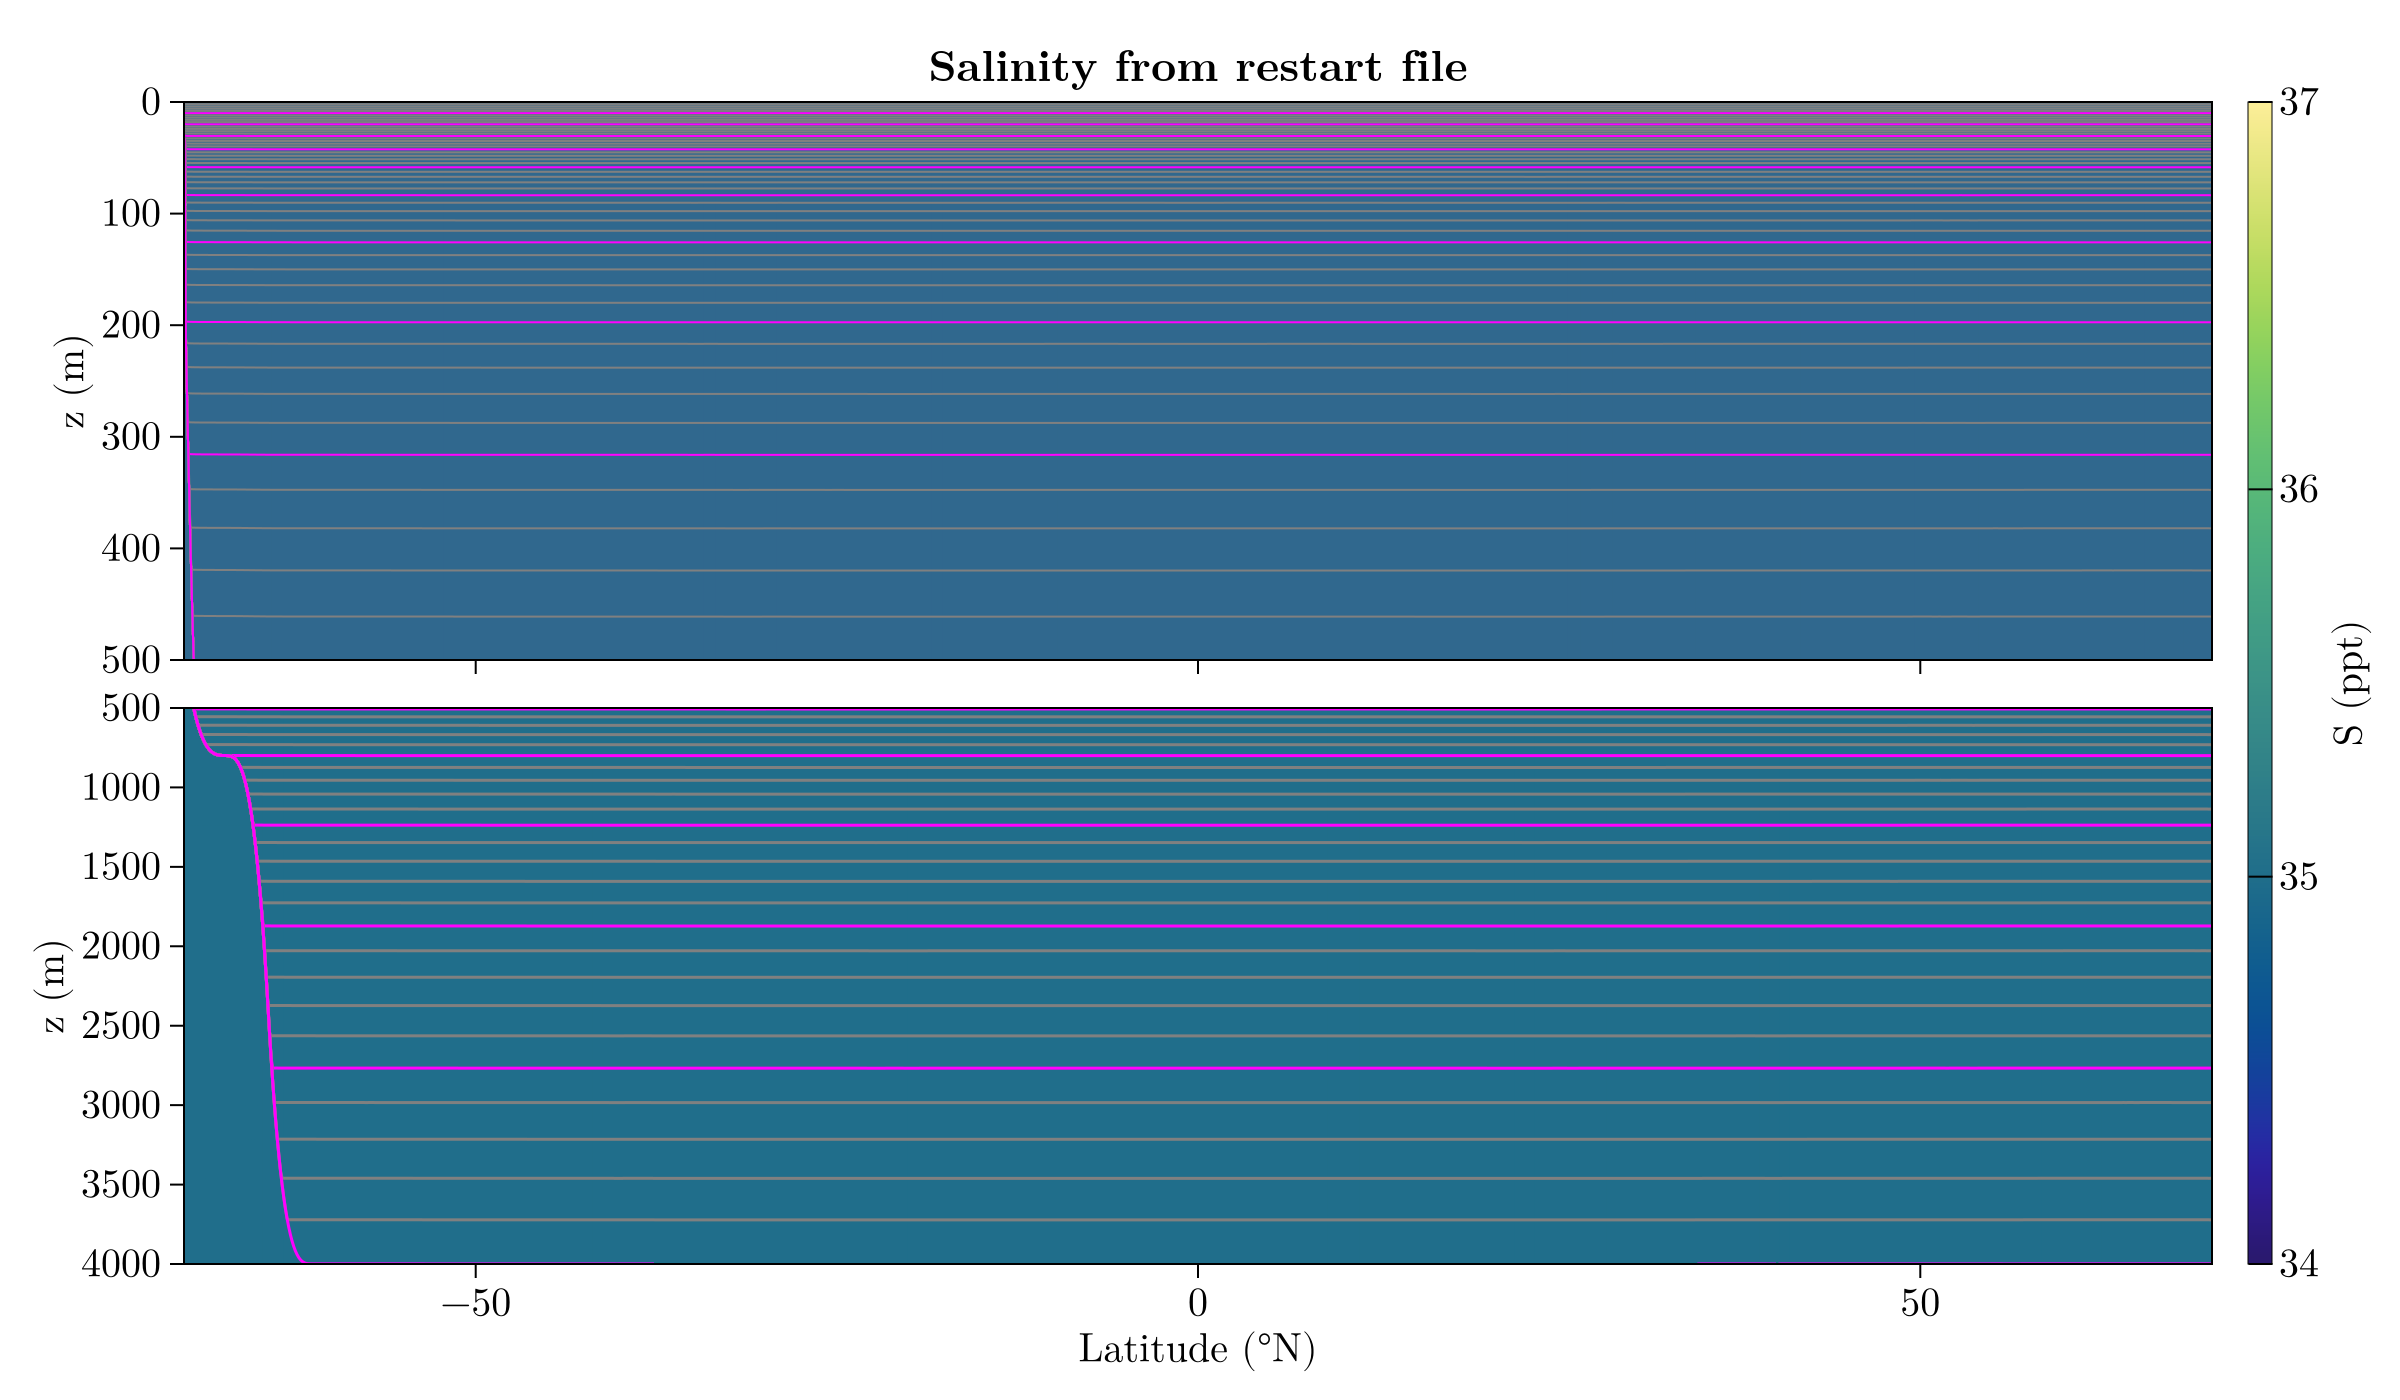

In [18]:
fig = Figure(size = (1200, 700))
colorrange = (34, 37)
depth_levels = 1:75
colormap = :haline

axtop = Axis(fig[1, 1], xlabel = "Latitude (°N)", ylabel = "z (m)", title = "Salinity from restart file")
hidexdecorations!(axtop, ticks = false)
hm = heatmap!(axtop, yh, z, S; colorrange)
for i ∈ depth_levels
    if i % 5 == 0
        lines!(axtop, yh, ∫h_test[:, i], color = :magenta, linewidth = 1)
    else
        lines!(axtop, yh, ∫h_test[:, i], color = :grey, linewidth = 1)
    end
end
ylims!(axtop, 0, 500)
axtop.yreversed = true

axbot = Axis(fig[2, 1], xlabel = "Latitude (°N)", ylabel = "z (m)", yreversed = true)
hm = heatmap!(axbot, yh, z, S; colorrange, colormap)
for i ∈ depth_levels
    if i % 5 == 0
        lines!(axbot, yh, ∫h_test[:, i], color = :magenta)
    else
        lines!(axbot, yh, ∫h_test[:, i], color = :grey)
    end
end
ylims!(axbot, 500, 4000)
axbot.yreversed = true

Colorbar(fig[1:2, 2], hm, label = "S (ppt)")

fig

In [32]:
unique(round.(S, digits = 9))

2-element Vector{Float64}:
 35.0
 34.999999999

This shows (suggests?) that salinity is constant at 35ppt throughout the simulation.
I knew it was constant but did not know how to find the value.
After seeing the above and double checking I find:

```
! === module MOM_state_initialization ===
TS_CONFIG = "linear"
T_REF = 10.0
S_REF = 35.0
T_TOP = 10
T_RANGE = 5
S_TOP = 35
S_RANGE = 0
```

which tells the story.
So I should be able to create a salinity variable to restart from that is `similar` to the temperature size in the HYCOM output.

## HYCOM restart file from zstar restart file

In [84]:
ds = NCDataset(Hogg_run, maskingvalue = Float32(NaN))

find_nan = .!isnan.(ds["thetao"][:, :, :, end]) .== true

close(ds)
    
ds = NCDataset(rf, maskingvalue = Float32(NaN))
_ds = NCDataset("hycom_z_initial_conditions.nc", "c")

defVar(_ds, ds["lonh"])
defVar(_ds, ds["lath"])
defVar(_ds, ds["Layer"])

T = ds["Temp"][:, :, :, end]
T .*= find_nan
replace!(T, 0 => Float32(1.0e20))

S = ds["Salt"][:, :, :, end]
S .*= find_nan
replace!(S, 0 => Float32(1.0e20))

h = ds["h"][:, :, :, end]
h .*= find_nan
replace!(h, 0 => Float32(1.0e20))

defVar(_ds, "Temp", T, ("lonh", "lath", "Layer"), fillvalue = Float32(1.0e20), 
       attrib = Dict("long_name" => "Temperature", "units" => "degC", "missing_value" => 1.0e20)
)
defVar(_ds, "h", h, ("lonh", "lath", "Layer"), fillvalue = Float32(1.0e20), 
       attrib = Dict("long_name" => "Thickness", "units" => "m", "missing_value" => 1.0e20)
)
defVar(_ds, "Salt", S, ("lonh", "lath", "Layer"), fillvalue = Float32(1.0e20), 
       attrib = Dict("long_name" => "Salinity", "units" => "PPT", "missing_value" => 1.0e20)
)

close(_ds)

close(ds)

closed Dataset

## HYCOM initial conditions file from HYCOM output

In [56]:
Hogg_HYCOM_run = "/g/data/x77/amh157/anu-tub/outputs/anu-tub-hycom1-500/output342/ocean_month.nc"
Hogg_HYCOM_static = "/g/data/x77/amh157/anu-tub/outputs/anu-tub-hycom1-500/output342/ocean_static.nc"
generate_tub_ics!("hycom_initial_conditions.nc", Hogg_HYCOM_run, Hogg_HYCOM_static)

[ Info: Initial conditions saved to hycom_initial_conditions.nc


Now check that the temperature and layers match well enough to the data they were taken from.

In [49]:
ds = NCDataset("hycom_initial_conditions.nc")
hᵢ = ds["h"][80, :, :]
∫h_testᵢ = cumsum(h, dims = 2)
θᵢ = ds["Temp"][80, :, :]
close(ds)

ds = NCDataset(Hogg_HYCOM_run)
h = ds["thkcello"][80, :, :, end]
∫h_test = cumsum(h, dims = 2)
θ = ds["thetao"][80, :, :, end]
yh = ds["yh"][:]
z = ds["zl"][:]
close(ds)

abs_err_θ = sum(abs.(θ .- θᵢ))
abs_err_h = sum(abs.(h .- hᵢ))
println("|θ - θᵢ| = $(abs_err_θ)")
println("|h - hᵢ| = $(abs_err_h)")

|θ - θᵢ| = 0.0
|h - hᵢ| = 0.0


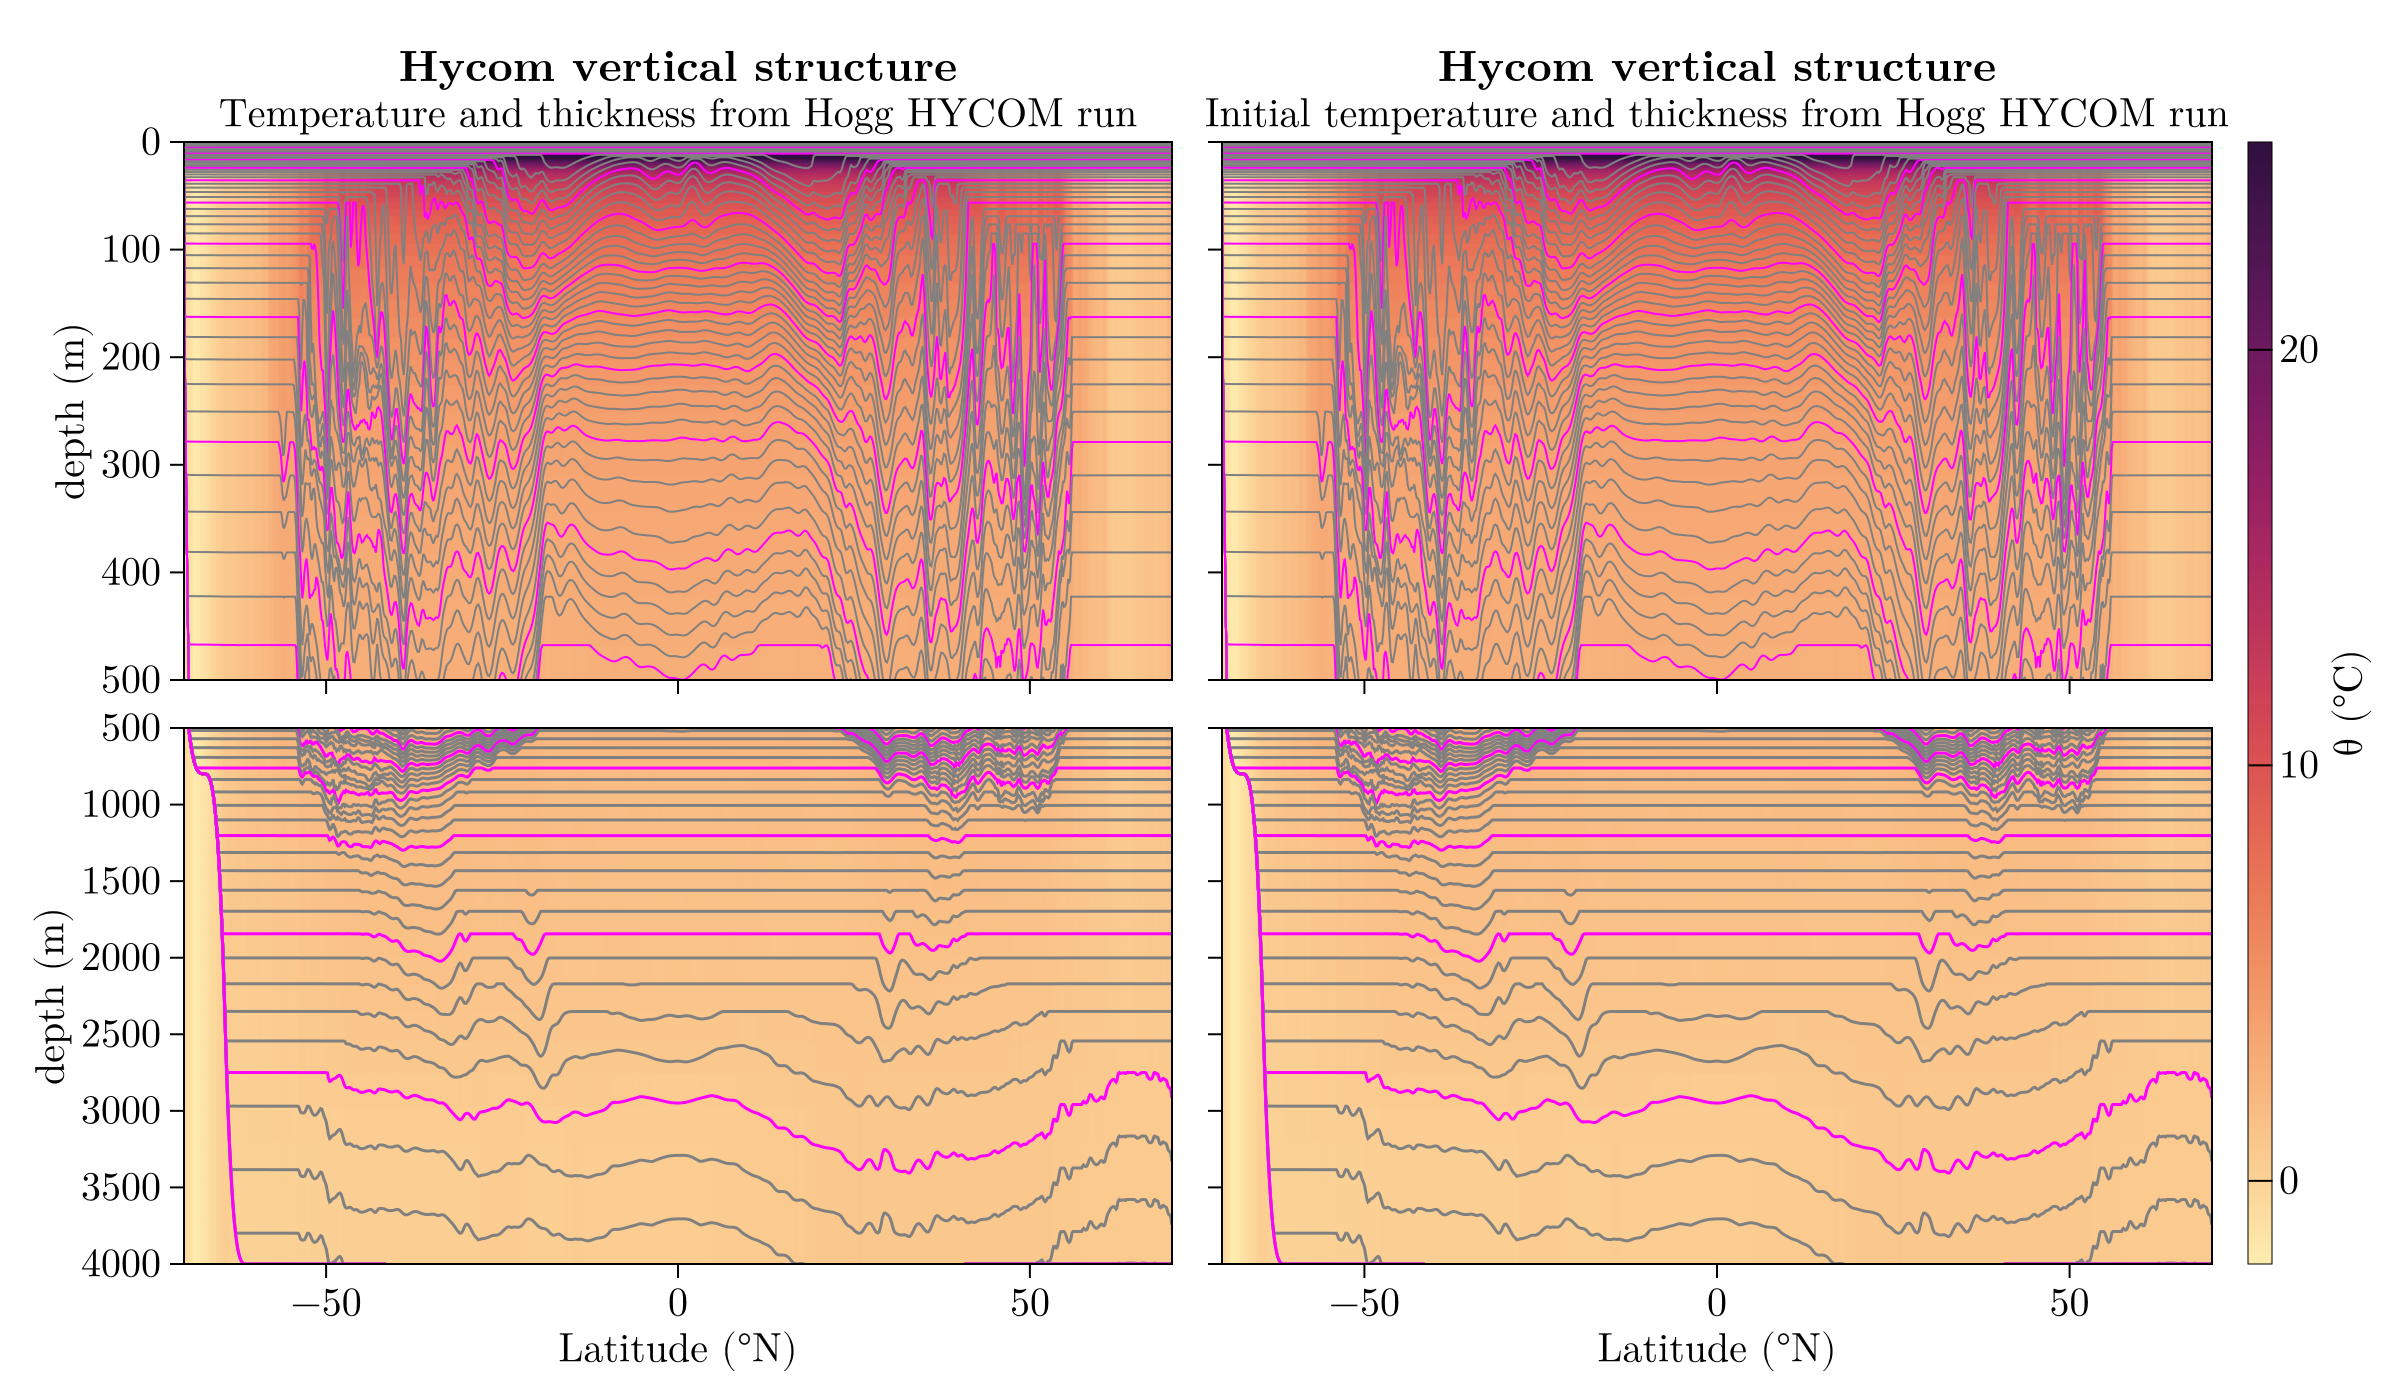

In [57]:
fig = Figure(size = (1200, 700))
colorrange = (-2, 25)
depth_levels = 1:75

axtop = Axis(fig[1, 1], xlabel = "Latitude (°N)", ylabel = "depth (m)", 
            title = "Hycom vertical structure", subtitle = "Temperature and thickness from Hogg HYCOM run")
hidexdecorations!(axtop, ticks = false)
hm = heatmap!(axtop, yh, z, θ; colorrange, colormap = :matter)
for i ∈ depth_levels
    if i % 5 == 0
        lines!(axtop, yh, ∫h_test[:, i], color = :magenta, linewidth = 1)
    else
        lines!(axtop, yh, ∫h_test[:, i], color = :grey, linewidth = 1)
    end
end
ylims!(axtop, 0, 500)
axtop.yreversed = true

axbot = Axis(fig[2, 1], xlabel = "Latitude (°N)", ylabel = "depth (m)", yreversed = true)
hm = heatmap!(axbot, yh, z, θ; colorrange, colormap = :matter)
for i ∈ depth_levels
    if i % 5 == 0
        lines!(axbot, yh, ∫h_test[:, i], color = :magenta)
    else
        lines!(axbot, yh, ∫h_test[:, i], color = :grey)
    end
end
ylims!(axbot, 500, 4000)
axbot.yreversed = true

axtop = Axis(fig[1, 2], xlabel = "Latitude (°N)", ylabel = "depth (m)", 
            title = "Hycom vertical structure", subtitle = "Initial temperature and thickness from Hogg HYCOM run")
hidexdecorations!(axtop, ticks = false)
hideydecorations!(axtop, ticks = false)
hm = heatmap!(axtop, yh, z, θᵢ; colorrange, colormap = :matter)
for i ∈ depth_levels
    if i % 5 == 0
        lines!(axtop, yh, ∫h_testᵢ[:, i], color = :magenta, linewidth = 1)
    else
        lines!(axtop, yh, ∫h_testᵢ[:, i], color = :grey, linewidth = 1)
    end
end
ylims!(axtop, 0, 500)
axtop.yreversed = true

axbot = Axis(fig[2, 2], xlabel = "Latitude (°N)", ylabel = "depth (m)", yreversed = true)
hm = heatmap!(axbot, yh, z, θᵢ; colorrange, colormap = :matter)
hideydecorations!(axbot, ticks = false)
for i ∈ depth_levels
    if i % 5 == 0
        lines!(axbot, yh, ∫h_testᵢ[:, i], color = :magenta)
    else
        lines!(axbot, yh, ∫h_testᵢ[:, i], color = :grey)
    end
end
ylims!(axbot, 500, 4000)
axbot.yreversed = true

Colorbar(fig[1:2, 3], hm, label = "θ (°C)")

fig

Above all looks ok and there is no error between the values so assume all is correctly set.
Check that the interface heigth from sea level `e` or `eta` in the ic file looks ok.

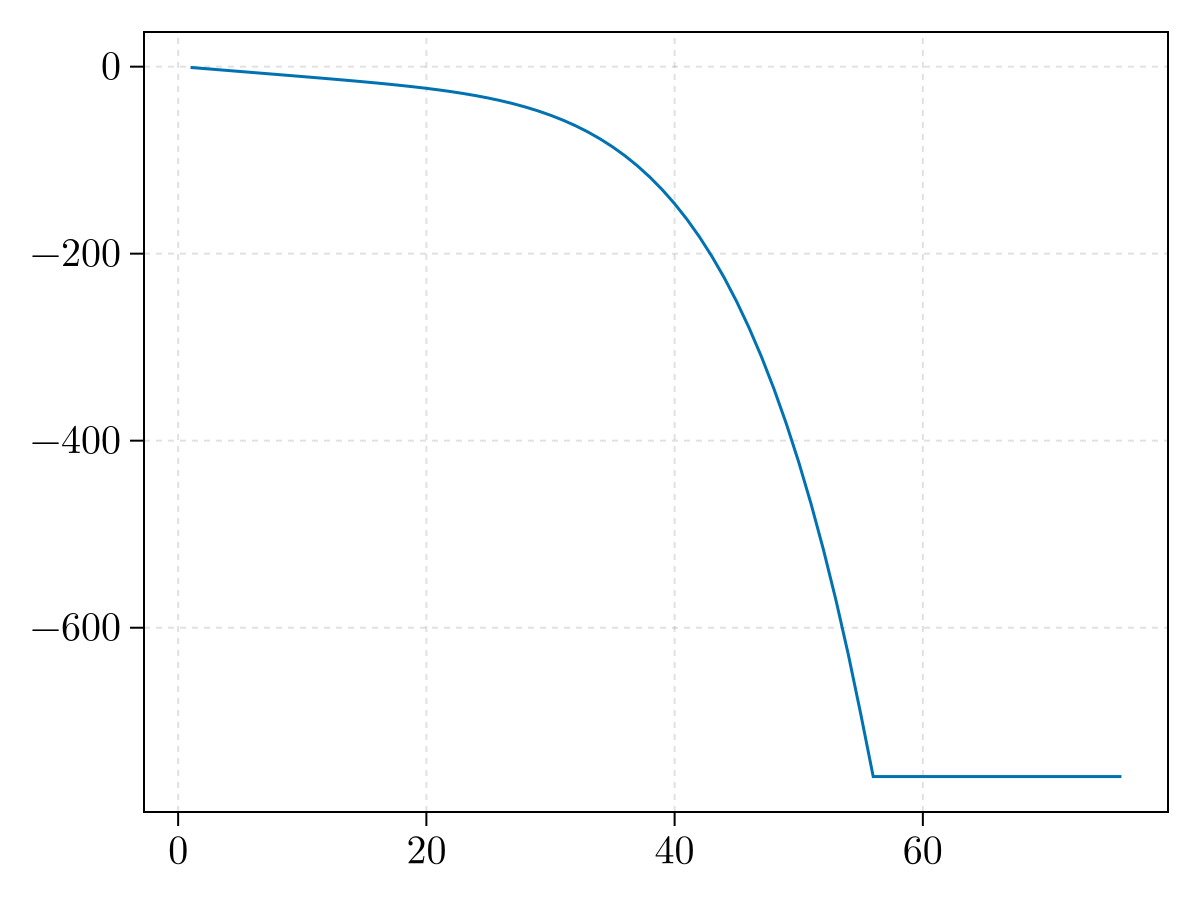

In [25]:
ds = NCDataset("hycom_initial_conditions.nc")
e = ds["eta"][:, :, :]
close(ds)

fig, ax = lines(1:76, e[10, 20, :])
fig

## z* initial conditions file from z* output

To have a closer comparison, I am going to generate the same initial condition file (temperature, salinity, thickness and interface height from mean sea level) from z* output at the same snapshot I created the HYCOM output above.

In [59]:
Hogg_zstar_run = "/g/data/x77/amh157/anu-tub/outputs/anu-tub-n4/output400/ocean_month.nc"
Hogg_zstar_static = "/g/data/x77/amh157/anu-tub/outputs/anu-tub-n4/output400/ocean_static.nc"
generate_tub_ics!("zstar_initial_conditions.nc", Hogg_zstar_run, Hogg_zstar_static)

[ Info: Initial conditions saved to zstar_initial_conditions.nc


In [63]:
ds = NCDataset("zstar_initial_conditions.nc")
hᵢ = ds["h"][80, :, :]
∫h_testᵢ = cumsum(h, dims = 2)
θᵢ = ds["Temp"][80, :, :]
close(ds)

ds = NCDataset(Hogg_zstar_run)
h = ds["thkcello"][80, :, :, end]
∫h_test = cumsum(h, dims = 2)
θ = ds["thetao"][80, :, :, end]
yh = ds["yh"][:]
z = ds["zl"][:]
close(ds)

abs_err_θ = sum(abs.(θ .- θᵢ))
abs_err_h = sum(abs.(h .- hᵢ))
println("|θ - θᵢ| = $(abs_err_θ)")
println("|h - hᵢ| = $(abs_err_h)")

|θ - θᵢ| = 0.0
|h - hᵢ| = 0.0


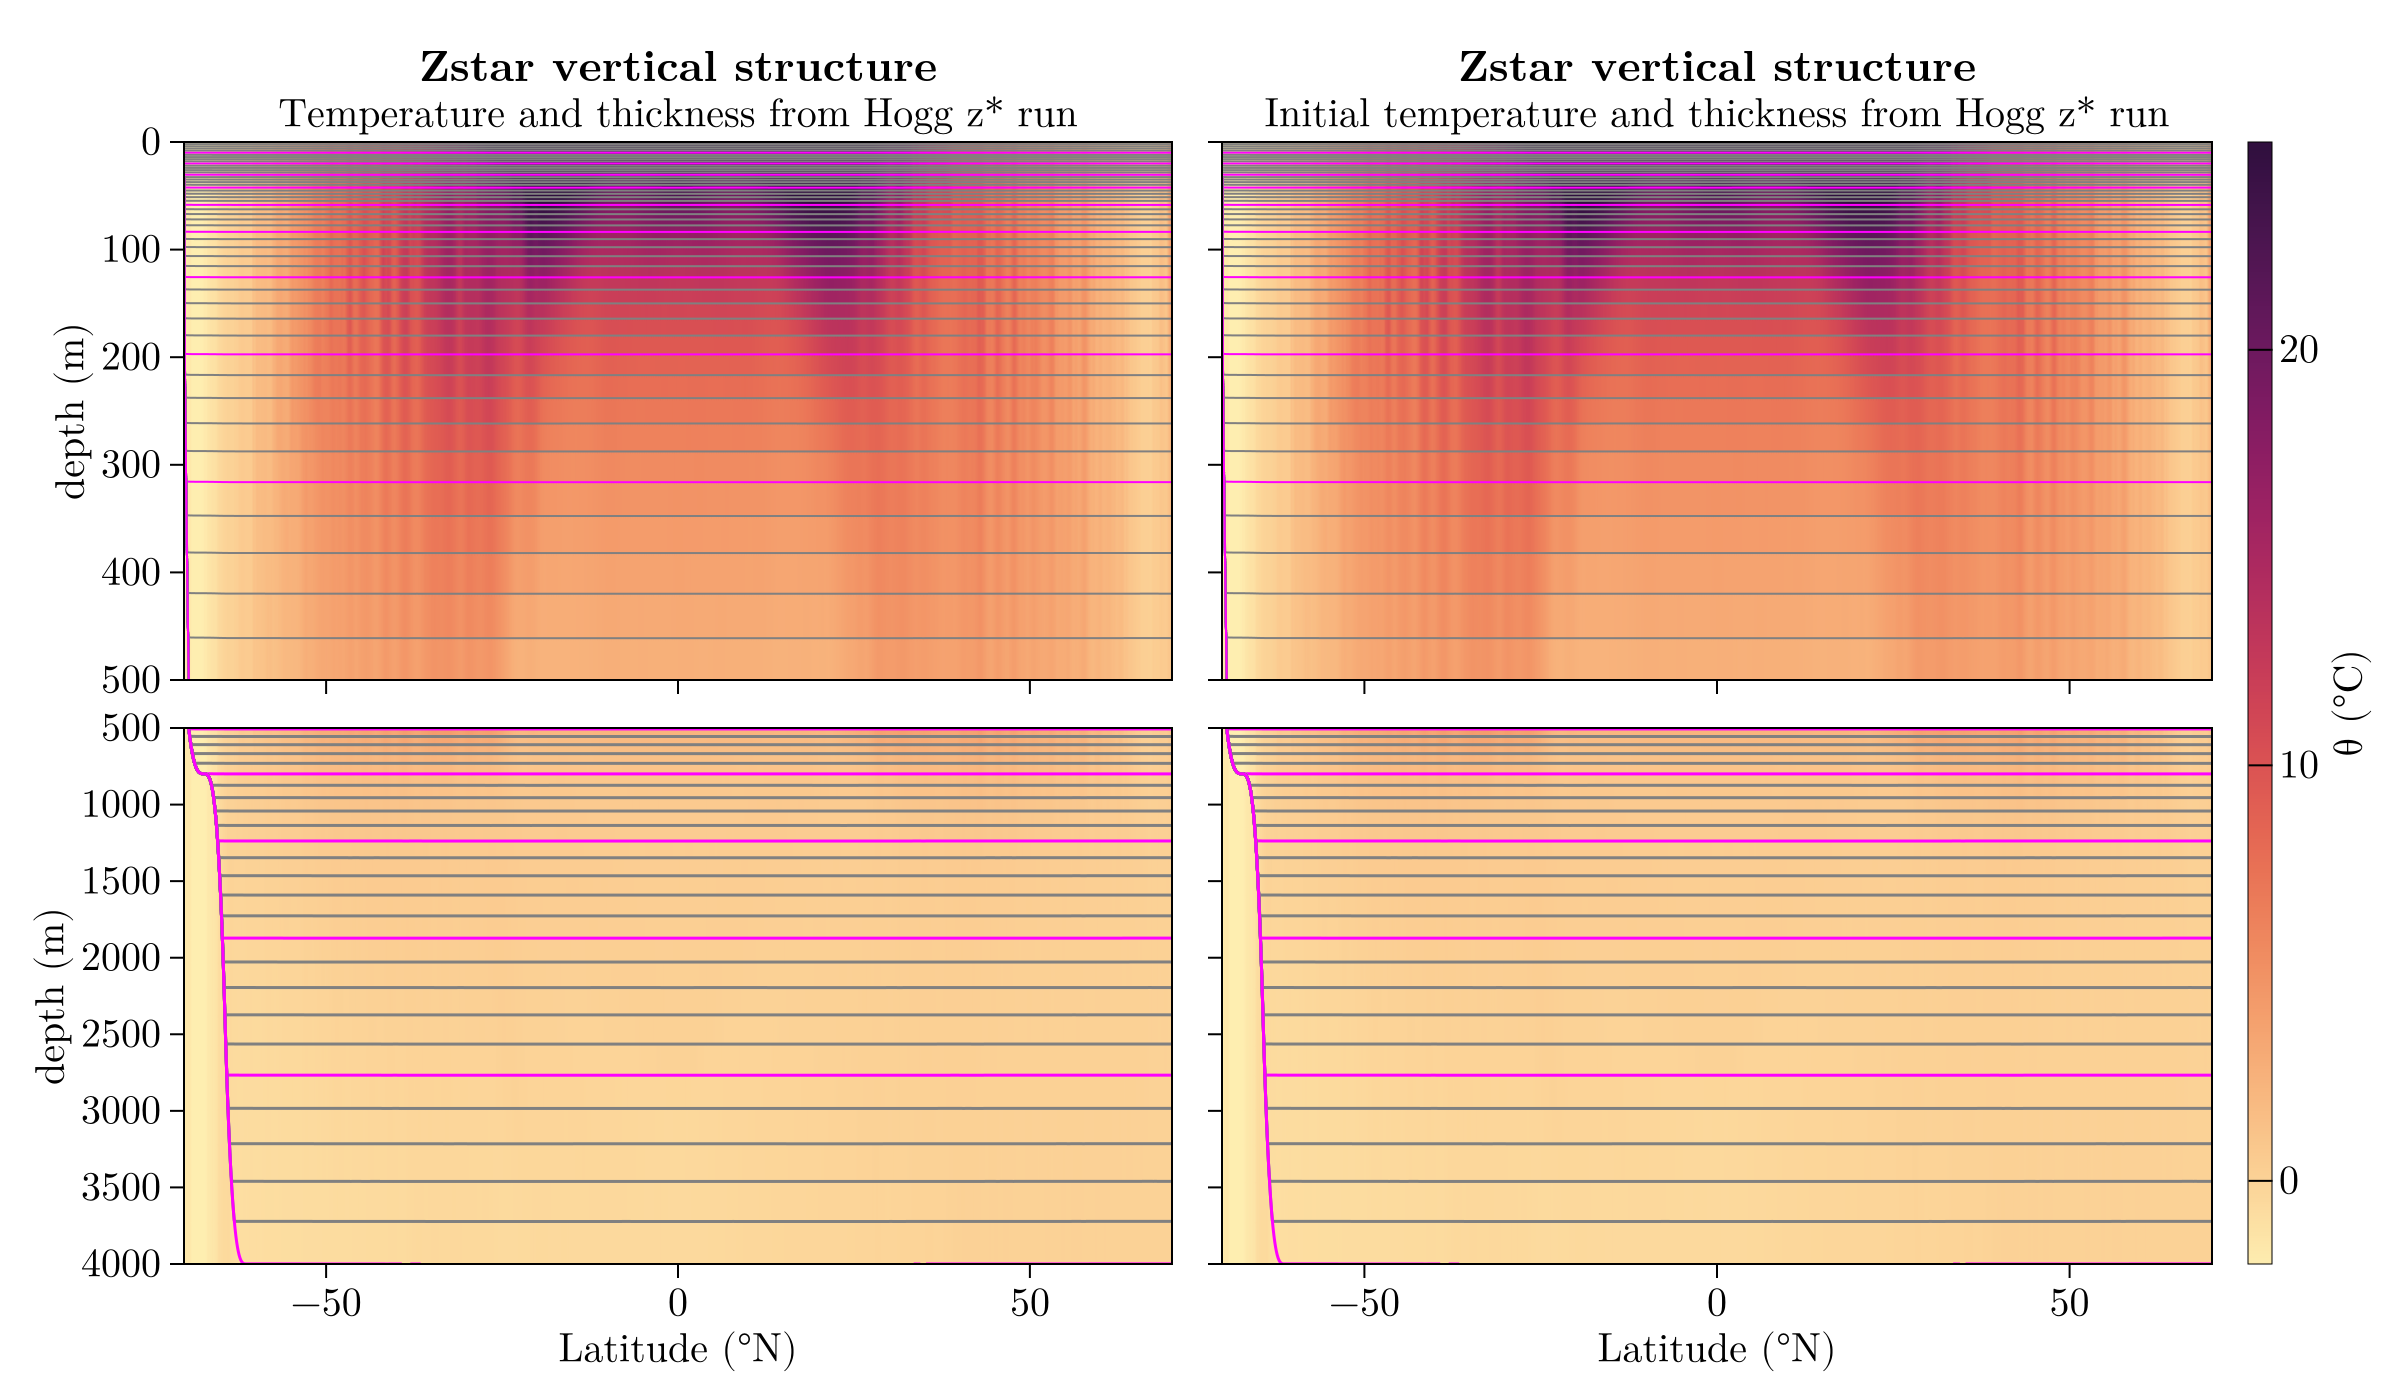

In [65]:
fig = Figure(size = (1200, 700))
colorrange = (-2, 25)
depth_levels = 1:75

axtop = Axis(fig[1, 1], xlabel = "Latitude (°N)", ylabel = "depth (m)", 
            title = "Zstar vertical structure", subtitle = "Temperature and thickness from Hogg z* run")
hidexdecorations!(axtop, ticks = false)
hm = heatmap!(axtop, yh, z, θ; colorrange, colormap = :matter)
for i ∈ depth_levels
    if i % 5 == 0
        lines!(axtop, yh, ∫h_test[:, i], color = :magenta, linewidth = 1)
    else
        lines!(axtop, yh, ∫h_test[:, i], color = :grey, linewidth = 1)
    end
end
ylims!(axtop, 0, 500)
axtop.yreversed = true

axbot = Axis(fig[2, 1], xlabel = "Latitude (°N)", ylabel = "depth (m)", yreversed = true)
hm = heatmap!(axbot, yh, z, θ; colorrange, colormap = :matter)
for i ∈ depth_levels
    if i % 5 == 0
        lines!(axbot, yh, ∫h_test[:, i], color = :magenta)
    else
        lines!(axbot, yh, ∫h_test[:, i], color = :grey)
    end
end
ylims!(axbot, 500, 4000)
axbot.yreversed = true

axtop = Axis(fig[1, 2], xlabel = "Latitude (°N)", ylabel = "depth (m)", 
            title = "Zstar vertical structure", subtitle = "Initial temperature and thickness from Hogg z* run")
hidexdecorations!(axtop, ticks = false)
hideydecorations!(axtop, ticks = false)
hm = heatmap!(axtop, yh, z, θᵢ; colorrange, colormap = :matter)
for i ∈ depth_levels
    if i % 5 == 0
        lines!(axtop, yh, ∫h_testᵢ[:, i], color = :magenta, linewidth = 1)
    else
        lines!(axtop, yh, ∫h_testᵢ[:, i], color = :grey, linewidth = 1)
    end
end
ylims!(axtop, 0, 500)
axtop.yreversed = true

axbot = Axis(fig[2, 2], xlabel = "Latitude (°N)", ylabel = "depth (m)", yreversed = true)
hm = heatmap!(axbot, yh, z, θᵢ; colorrange, colormap = :matter)
hideydecorations!(axbot, ticks = false)
for i ∈ depth_levels
    if i % 5 == 0
        lines!(axbot, yh, ∫h_testᵢ[:, i], color = :magenta)
    else
        lines!(axbot, yh, ∫h_testᵢ[:, i], color = :grey)
    end
end
ylims!(axbot, 500, 4000)
axbot.yreversed = true

Colorbar(fig[1:2, 3], hm, label = "θ (°C)")

fig